# **Simple Trading Strategy**



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
%matplotlib inline

In [ ]:
#upload required stock data
files.upload()

In [3]:
#Read the file and assign the first column as the Data Frame index'''
stk = pd.read_csv('/content/drive/Othercomputers/My Laptop/Data Analysis/Datasets/facebook.csv', index_col= 0, parse_dates= True)
stk.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,20.400000,20.510000,19.990000,20.049999,19.459270,4157500
2015-01-02,20.129999,20.280001,19.809999,20.129999,19.536913,2842000
2015-01-05,20.129999,20.190001,19.700001,19.790001,19.206934,4948800
2015-01-06,19.820000,19.840000,19.170000,19.190001,18.624611,4944100
2015-01-07,19.330000,19.500000,19.080000,19.139999,18.576082,8045200


**1. Munging stock data and add two columns - MA10 and MA50**

In [4]:
#import stock data, add two columns - MA10 and MA50
#use dropna to remove any "Not a Number" data

stk['MA10'] = stk['Close'].rolling(10).mean()
stk['MA50'] = stk['Close'].rolling(50).mean()
stk = stk.dropna()
stk.head()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50
Date,,,,,,,,
2015-03-13,22.559999,22.760000,22.250000,22.700001,22.116024,8982200,22.648,21.0174
2015-03-16,22.879999,23.110001,22.730000,22.969999,22.379078,5923900,22.685,21.0758
2015-03-17,22.920000,23.260000,22.760000,23.250000,22.651876,7497500,22.792,21.1382
2015-03-18,23.250000,23.370001,22.660000,22.870001,22.281652,10337600,22.836,21.1998
2015-03-19,22.950001,23.299999,22.780001,23.219999,22.622650,7768900,22.872,21.2804


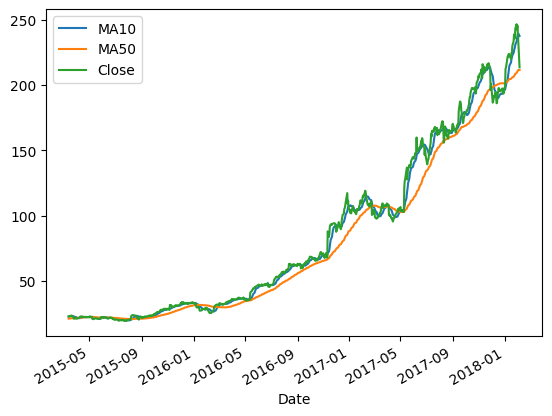

In [5]:
#Plots the timeseries
stk['MA10'].plot(label = 'MA10')
stk['MA50'].plot(label = 'MA50')
stk['Close'].plot(label = 'Close')
plt.legend()
plt.show()

**2. Add "Shares" column to make decisions based on the strategy**

In [7]:
#Add a new column "Shares", if MA10>MA50, denote as 1 (long one share of stock), otherwise, denote as 0 (do nothing)
stk['Shares'] = [1 if stk.loc[ei, 'MA10']>stk.loc[ei, 'MA50'] else 0 for ei in stk.index]

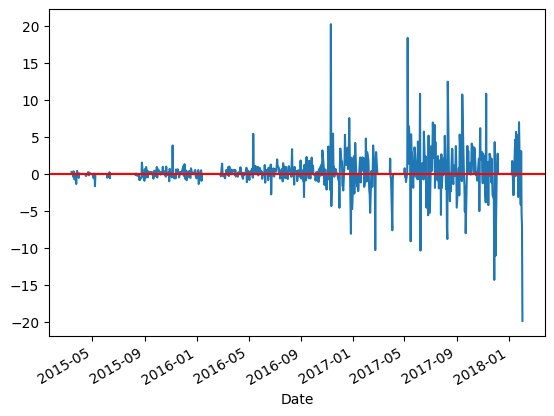

In [8]:
#Add a new column "Profit" using List Comprehension, for any rows in stk, if Shares=1, the profit is calculated as the close price of
#tomorrow - the close price of today. Otherwise the profit is 0.

#Plot a graph to show the Profit/Loss

stk['Close1'] = stk['Close'].shift(-1)
stk['Profit'] = [stk.loc[ei, 'Close1'] - stk.loc[ei, 'Close'] if stk.loc[ei, 'Shares']==1 else 0 for ei in stk.index]
stk['Profit'].plot()
plt.axhline(y=0, color='red')

**3. Use .cumsum() to diplay the model`s performance if you follow the strategy**

In [9]:
#Use .cumsum() to calculate the accumulated wealth over the period
stk['wealth'] = stk['Profit'].cumsum()
stk.tail()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,Shares,Close1,Profit,wealth
Date,,,,,,,,,,,,
2018-01-30,241.110001,246.419998,238.410004,242.720001,242.720001,14270800,235.692003,210.030001,1,245.800003,3.080002,177.820011
2018-01-31,245.770004,249.270004,244.449997,245.800003,245.800003,11964400,237.800003,210.713801,1,240.500000,-5.300003,172.520008
2018-02-01,238.520004,246.899994,238.059998,240.500000,240.500000,12980600,239.406003,211.296601,1,233.520004,-6.979996,165.540012
2018-02-02,237.000000,237.970001,231.169998,233.520004,233.520004,17961600,239.747003,211.685401,1,213.699997,-19.820007,145.720005
2018-02-05,227.000000,233.229996,205.000000,213.699997,213.699997,28869000,237.748003,211.638401,1,NaN,NaN,NaN


Text(0.5, 1.0, 'Total money you win is 145.72000500000001')

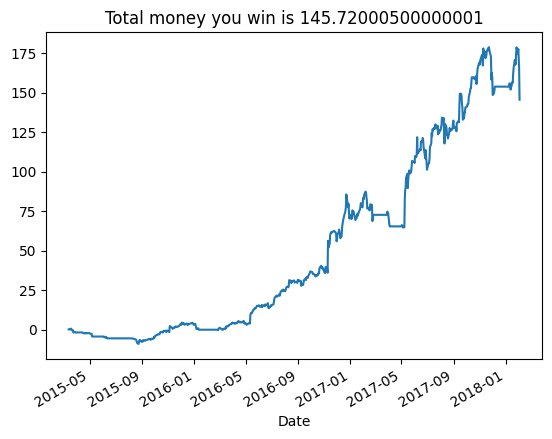

In [10]:
#Graphs the wealth to show the growth of profit over time
stk['wealth'].plot()
plt.title('Total money you win is {}'.format(stk.loc[stk.index[-2], 'wealth']))